# ResuMatch — Exploration Notebook
EDA, model selection experiments, and scoring analysis.

In [4]:
import sys
sys.path.insert(0, '..')

from src.scorer import score
from src.similarity import get_model
from src.parser import parse_sections
from src.keywords import keyword_gap_analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

model = get_model()
print('Imports OK')

c:\Coding_files\College\NLP_sem6\files\nlpsem6_venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Imports OK


## 1. Load Sample Data

In [5]:
with open('../data/samples/sample_resume.txt') as f:
    resume = f.read()

with open('../data/samples/sample_jd.txt') as f:
    jd = f.read()

print('Resume length:', len(resume.split()), 'words')
print('JD length:', len(jd.split()), 'words')

Resume length: 253 words
JD length: 230 words


## 2. Run Full Scoring Pipeline

In [6]:
result = score(resume, jd, model)

print(f"Overall Score     : {result['overall_score']}%")
print(f"Semantic Score    : {round(result['semantic_score']*100, 1)}%")
print(f"Keyword Match Rate: {round(result['keyword_gap']['match_rate']*100, 1)}%")
print(f"\nSection Scores:")
for k, v in result['section_scores'].items():
    print(f"  {k.capitalize():12}: {round(v*100,1) if v else 'N/A'}%")

  [scorer] similarity: 3.35s
  [scorer] parsing: 0.00s
  [scorer] sections: 0.20s
  [scorer] keywords: 0.02s
Overall Score     : 50.2%
Semantic Score    : 64.0%
Keyword Match Rate: 20.0%

Section Scores:
  Skills      : 64.2%
  Experience  : 64.3%
  Education   : 30.1%


## 3. Keyword Gap Visualization

Matched keywords: ['nlp', 'data', 'learning', 'machine learning', 'bert']
Missing keywords: ['experience', 'semantic', 'models', 'text', 'knowledge', 'production', 'contributions', 'science', 'classification', 'tech', 'machine', 'source', 'maintain', 'strong', 'text classification', 'extraction', 'open', 'preferred', 'pre trained', 'pre']
Extra keywords:   ['using', '2024', 'spacy', 'python', 'com', 'institute', 'github', 'fine tuning', 'john', 'fine']


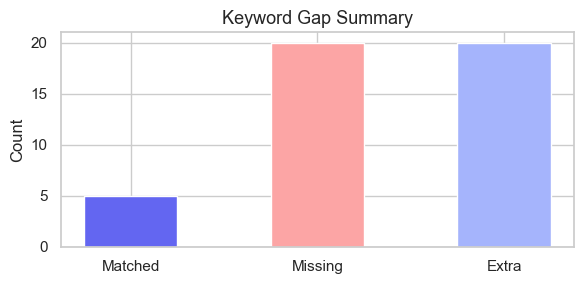

In [7]:
gap = result['keyword_gap']
print('Matched keywords:', gap['matched'])
print('Missing keywords:', gap['missing'])
print('Extra keywords:  ', gap['extra'][:10])

# Bar chart
fig, ax = plt.subplots(figsize=(6, 3))
counts = [len(gap['matched']), len(gap['missing']), len(gap['extra'])]
labels = ['Matched', 'Missing', 'Extra']
colors = ['#6366f1', '#fca5a5', '#a5b4fc']
ax.bar(labels, counts, color=colors, width=0.5)
ax.set_title('Keyword Gap Summary', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Model Comparison: SBERT vs TF-IDF Cosine

TF-IDF Cosine Similarity : 22.1%
SBERT Cosine Similarity  : 64.0%

Insight: SBERT captures semantic meaning even when exact words differ.
TF-IDF is purely lexical — misses synonyms and paraphrases.


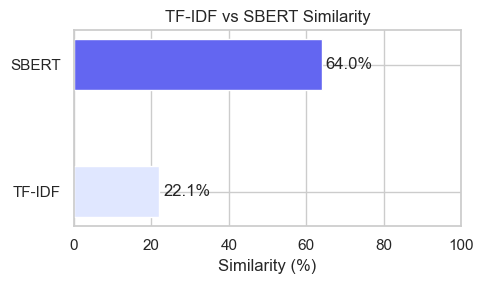

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# TF-IDF cosine
vec = TfidfVectorizer(stop_words='english')
tfidf_matrix = vec.fit_transform([resume, jd])
tfidf_score = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0]

# SBERT
sbert_score = result['semantic_score']

print(f"TF-IDF Cosine Similarity : {round(tfidf_score*100, 1)}%")
print(f"SBERT Cosine Similarity  : {round(sbert_score*100, 1)}%")
print()
print('Insight: SBERT captures semantic meaning even when exact words differ.')
print('TF-IDF is purely lexical — misses synonyms and paraphrases.')

fig, ax = plt.subplots(figsize=(5, 3))
ax.barh(['TF-IDF', 'SBERT'], [tfidf_score*100, sbert_score*100],
        color=['#e0e7ff', '#6366f1'], height=0.4)
ax.set_xlabel('Similarity (%)')
ax.set_xlim(0, 100)
ax.set_title('TF-IDF vs SBERT Similarity')
for i, v in enumerate([tfidf_score*100, sbert_score*100]):
    ax.text(v + 1, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

## 5. Section-wise Score Heatmap

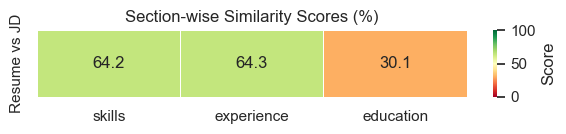

In [9]:
sec_scores = {k: round(v*100,1) for k, v in result['section_scores'].items() if v}
df = pd.DataFrame([sec_scores], index=['Resume vs JD'])

plt.figure(figsize=(6, 1.5))
sns.heatmap(df, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, cbar_kws={'label': 'Score'})
plt.title('Section-wise Similarity Scores (%)')
plt.tight_layout()
plt.show()